In [22]:
import numpy as np
import matplotlib.pyplot as plt

import sys, os
import h5py
sys.path.append('../')
import analysis_utils as utils
import get_final_hist_amps as get_hists
utils.load_plotting_setting()

from astropy.time import Time, TimeDelta
from astropy.coordinates import EarthLocation

In [57]:
from datetime import datetime
from zoneinfo import ZoneInfo

def str2timestamp(time_str):
    time_str = np.asarray(time_str)

    ret = np.empty(time_str.size)
    for i, str in enumerate(time_str):
        # Note: "Etc/GMT+5" is UTC-5, though the sign is reversed due to POSIX conventions.
        dt = datetime.strptime(str, "%Y-%m-%d %H:%M").replace(tzinfo=ZoneInfo("Etc/GMT+5"))
        ret[i] = dt.timestamp()
    return ret

In [23]:
def bin_events_day(hour_day, bins):
    ret = []
    for hours in hour_day:
        _hist, _ = np.histogram(hours, bins=bins)
        ret.append(_hist)

    return np.array(ret)

def get_local_hour(utc_offset, t_utc):
    t_locals = t_utc + TimeDelta(utc_offset * 3600, format='sec')

    t_local_hours = np.empty(t_locals.size)
    for i, t_local in enumerate(t_locals):
        t_local_hours[i] = t_local.datetime.hour + t_local.datetime.minute/60 + t_local.datetime.second/3600

    return t_local_hours

def group_into_days(hours):
    idx_day = np.where(np.diff(hours)<0)[0]

    hours_day = []
    for i, idx_end in enumerate(idx_day):
        if i == 0:
            idx_start = 0
        else:
            idx_start = idx_day[i-1]
        hours_day.append(hours[idx_start+1:idx_end+1])

    # Add the final day
    hours_day.append(hours[idx_end+1:])

    return hours_day

#### Bin the events in time to estimate the hourly rates

In [31]:
amp2kev_sphere_20241202 = 5945.245097647231
amp2kev_sphere_20250103 = 5923.2059527417405

# data_dir = r'C:\Users\yuhan\dm_nanospheres\data_processed\sphere_data'
data_dir = r'/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/sphere_data/final_recon_before_bg_rate_cut'

file0 = h5py.File(rf'{data_dir}/sphere_20241202_unbinned_amps.h5py')
file1 = h5py.File(rf'{data_dir}/sphere_20250103_unbinned_amps.h5py')

amps0 = file0['unbinned_amps']['amplitude'][:]
amps1 = file1['unbinned_amps']['amplitude'][:]
time0 = file0['unbinned_amps']['time'][:]
time1 = file1['unbinned_amps']['time'][:]

file0.close()
file1.close()

In [85]:
# Creat timestamps for binning
bins_str = []
for i in range(2, 18):
    for j in range(0, 24):
        bins_str.append(f'2024-12-{i:02} {j:02}:00')
bins_str.append('2024-12-18 00:00')
bins_str = np.asarray(bins_str)
bins_timstamps_0 = str2timestamp(bins_str)

bins_str = []
for i in range(4, 27):
    for j in range(0, 24):
        bins_str.append(f'2025-01-{i:02} {j:02}:00')
bins_str.append('2025-01-27 00:00')
bins_str = np.asarray(bins_str)

bins_timstamps_1 = str2timestamp(bins_str)

# Start binning events into each hour
thr_kev = 1500

hh_0, be = np.histogram(time0[np.abs(amps0)*amp2kev_sphere_20241202 > thr_kev], bins=bins_timstamps_0)
hist_day_solar_0 = np.reshape(hh_0, (16, 24))

hh_1, be = np.histogram(time1[np.abs(amps1)*amp2kev_sphere_20250103 > thr_kev], bins=bins_timstamps_1)
hist_day_solar_1 = np.reshape(hh_1, (23, 24))

In [ ]:
# thr_kev = 1500  # Consider events above 1.5 MeV only

# t0 = Time(time0, format='unix', scale='utc')
# t1 = Time(time1, format='unix', scale='utc')

# # Calculate the local time (UTC-5) during data taking
# utc_offset = -5

# _t0_local_hours = get_local_hour(utc_offset, t0[np.abs(amps0)*amp2kev_sphere_20241202 > thr_kev])
# _t1_local_hours = get_local_hour(utc_offset, t1[np.abs(amps1)*amp2kev_sphere_20250103 > thr_kev])

# hour_day_solar_0 = group_into_days(_t0_local_hours)
# hour_day_solar_1 = group_into_days(_t1_local_hours)

# # Bin events in individual days into histograms
# bins = np.linspace(0, 24, 25)
# bc = 0.5 * (bins[1:] + bins[:-1])

# hist_day_solar_0 = bin_events_day(hour_day_solar_0, bins)
# hist_day_solar_1 = bin_events_day(hour_day_solar_1, bins)

In [ ]:
# Read in the effective livetime (# of windows) for each day
# after livetime selection
npz_livetime = np.load('livetime_windows_day_before_bg_cut.npz')

livetime_sidereal_0 = npz_livetime['sidereal_0']
livetime_sidereal_1 = npz_livetime['sidereal_1']
livetime_solar_0 = npz_livetime['solar_0']
livetime_solar_1 = npz_livetime['solar_1']

npz_livetime.close()

# Calculate the hourly event rate
rate_solar_0    = hist_day_solar_0 / (livetime_solar_0 * 10e-3 / 3600)
rate_solar_1    = hist_day_solar_1 / (livetime_solar_1 * 10e-3 / 3600)

/var/folders/mb/1ggr_wms5jz0l7fkkc3b9xg80000gn/T/ipykernel_1687/3033262235.py:13: RuntimeWarning: invalid value encountered in divide
  rate_solar_0    = hist_day_solar_0 / (livetime_solar_0 * 10e-3 / 3600)
/var/folders/mb/1ggr_wms5jz0l7fkkc3b9xg80000gn/T/ipykernel_1687/3033262235.py:14: RuntimeWarning: invalid value encountered in divide
  rate_solar_1    = hist_day_solar_1 / (livetime_solar_1 * 10e-3 / 3600)


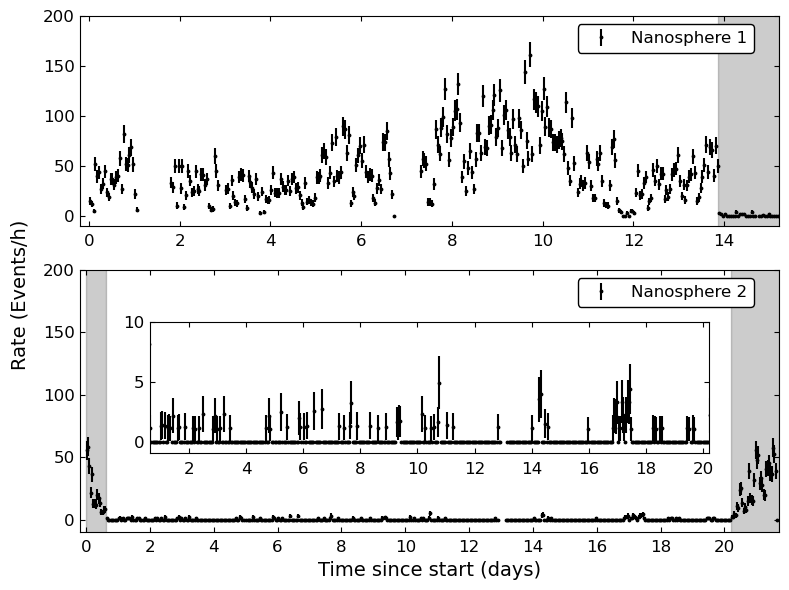

In [96]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6), height_ratios=[1, 1.25])

axes[0].errorbar((np.arange(rate_solar_0.flatten().size) - 17 + 0.5)/24, rate_solar_0.flatten(), yerr=np.sqrt(rate_solar_0.flatten()), fmt='.', color='k', markersize=3.5, label='Nanosphere 1')
axes[1].errorbar((np.arange(rate_solar_1.flatten().size) - 17 + 0.5)/24, rate_solar_1.flatten(), yerr=np.sqrt(rate_solar_1.flatten()), fmt='.', color='k', markersize=3.5, label='Nanosphere 2')

axes[0].fill_betweenx(np.arange(-100, 500, 50), (333 + 7.9319303/3600) / 24, (16*24-19)/24, color='k', alpha=0.2)
axes[1].fill_betweenx(np.arange(-100, 500, 50), 0, (15+54.1595662/3600) / 24, color='k', alpha=0.2)
axes[1].fill_betweenx(np.arange(-100, 500, 50), (485+5.3052022/3600)/24, (22*24-7)/24, color='k', alpha=0.2)

axes[0].set_xlim(-0.2, (16*24-19)/24)
axes[1].set_xlim(-0.2, (22*24-7)/24)

for ax in axes:
    ax.set_ylim(-10, 200)

for ax in axes:
    ax.legend(frameon=True, loc='upper left', bbox_to_anchor=(0.7, 1), edgecolor='k', framealpha=1)

axes[0].set_xticks(np.arange(0, 16, 2))  # every 2 hours
axes[0].tick_params(axis='x', which='major', pad=6)

axes[1].set_xticks(np.arange(0, 22, 2))
axes[1].tick_params(axis='x', which='major', pad=6)

axes[1].set_xlabel('Time since start (days)')
fig.supylabel('Rate (Events/h)', fontsize=14, x=0.02)

inset_ax = axes[1].inset_axes([0.1, 0.3, 0.8, 0.5])
inset_ax.errorbar((np.arange(rate_solar_1.flatten().size) - 17 + 0.5)/24, rate_solar_1.flatten(), yerr=np.sqrt(rate_solar_1.flatten()), fmt='.', color='k', markersize=3.5)
inset_ax.set_xlim((15+54.1595662/3600) / 24, (485+5.3052022/3600) / 24)
inset_ax.set_ylim(-1, 10)
inset_ax.set_xticks(np.arange(2, 22, 2))
inset_ax.tick_params(axis='x', which='major', pad=6)

fig.tight_layout()
plt.savefig(r'../paper_plots/hourly_rate_spheres.pdf', dpi=600)

In [ ]:
# Cut data after  2024/12/17 14:00:00 (Nanosphere 1)
# Cut data before 2025/01/05 08:00:00 (Nanosphere 2)
# Cut data after  2025/01/24 22:00:00 (Nanosphere 2)

time_str = np.array(['2024-12-17 14:00', '2025-01-05 08:00', '2025-01-24 22:00'])
timestamps = str2timestamp(time_str)
print(timestamps[0])
print(timestamps[1])
print(timestamps[2])

1734462000.0
1736082000.0
1737774000.0


In [10]:
t_cut_end_actual_0 = 1734462007.9319303

t_cut_start_actual_1 = 1736082054.1595662
t_cut_end_actual_1 = 1737774005.3052022

#### Histograms after the background rate cut

In [11]:
# out_dir = r'C:\Users\yuhan\dm_nanospheres\data_processed\sphere_data'
out_dir = r'/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/sphere_data'

outfile_name = 'sphere_20241202_recon_all_bg.h5py'
with h5py.File(os.path.join(out_dir, outfile_name), 'r') as fout:
    g = fout['recon_data_all']
    bc_0 = g['bc'][:]

    hist_all_0 = g['hist_all'][:]
    hist_det_0 = g['hist_det'][:]
    hist_det_noise_0 = g['hist_det_noise'][:]
    hist_det_noise_chi2_0 = g['hist_det_noise_chi2'][:]
    hist_det_noise_bg_0 = g['hist_det_noise_bg'][:]
    hist_det_noise_chi2_bg_0 = g['hist_det_noise_chi2_bg'][:]
    livetime_0 = g.attrs['livetime_sec']

    fout.close()

outfile_name = 'sphere_20250103_recon_all_bg.h5py'
with h5py.File(os.path.join(out_dir, outfile_name), 'r') as fout:
    g = fout['recon_data_all']
    bc_1 = g['bc'][:]

    hist_all_1 = g['hist_all'][:]
    hist_det_1 = g['hist_det'][:]
    hist_det_noise_1 = g['hist_det_noise'][:]
    hist_det_noise_chi2_1 = g['hist_det_noise_chi2'][:]
    hist_det_noise_bg_1 = g['hist_det_noise_bg'][:]
    hist_det_noise_chi2_bg_1 = g['hist_det_noise_chi2_bg'][:]
    livetime_1 = g.attrs['livetime_sec']

    fout.close()

amp2kev_sphere_20241202 = 5945.245097647231
amp2kev_sphere_20250103 = 5923.2059527417405
file0 = h5py.File(rf'/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/sphere_data/sphere_20241202_unbinned_amps_bg.h5py')
file1 = h5py.File(rf'/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/sphere_data/sphere_20250103_unbinned_amps_bg.h5py')

amps0 = file0['unbinned_amps']['amplitude'][:]
amps1 = file1['unbinned_amps']['amplitude'][:]
file0.close()
file1.close()

amps_kev_0 = np.abs(amps0 * amp2kev_sphere_20241202)
amps_kev_1 = np.abs(amps1 * amp2kev_sphere_20250103)
# amps_kev = np.concatenate([amps_kev_0, amps_kev_1])

bins = np.arange(0, 10000, 50)
bc = 0.5 * (bins[1:] + bins[:-1])
hist_0 , be = np.histogram(amps_kev_0, bins)
hist_1 , be = np.histogram(amps_kev_1, bins)

# combined_hist, be = np.histogram(amps_kev, bins)

In [18]:
thr = 1400
print(amps_kev_0[amps_kev_0 > thr].size)
print(amps_kev_1[amps_kev_1 > thr].size)

20087
290


In [130]:
print(livetime_0)
print(livetime_1)

925704.8918000001
1328088.789


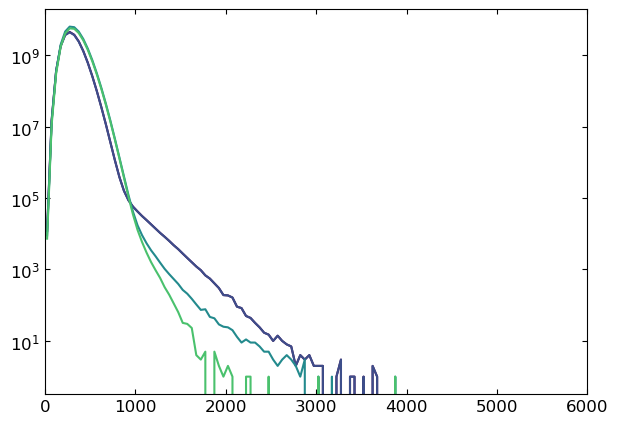

In [21]:
plt.plot(bc_0, hist_det_noise_chi2_0)
plt.plot(bc_0, hist_det_noise_chi2_bg_0)

plt.plot(bc_1, hist_det_noise_chi2_1)
plt.plot(bc_1, hist_det_noise_chi2_bg_1)
# plt.plot(bc, hist_1)

plt.xlim(0, 6000)

plt.yscale('log')